# Notebook 2 — Perturbação em log-mel + inversão + três reconstruções

## Pergunta

Agora a intervenção é definida no mesmo domínio que a CNN e o LIME usam:

$$
L
=
\log(1+M).
$$

Primeiro construímos uma versão perturbada:

$$
\widetilde{L}.
$$

Depois realizamos essa intervenção como áudio:

$$
\widetilde{L}
\rightarrow
\widetilde{M}
\rightarrow
\widetilde{P}
\rightarrow
\widetilde{A}
\rightarrow
\widetilde{x}.
$$

A etapa mel para STFT é fixa para todos os operadores.

Depois, a mesma magnitude STFT alvo $\widetilde{A}$ é entregue a:

- `OP`;
- `GL_ORIG64`;
- `GL_RAND64`.

Assim podemos separar:

1. inversão de features;
2. reconstrução de fase;
3. efeito downstream na CNN.


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

ART = Path("artifacts_logmel")

required_files = [
    ART / "tiny_bird_cnn_logmel.pt",
    ART / "config_logmel.json",
    ART / "test_data_and_lime_logmel.npz",
    ART / "mel_filterbank.npy",
    ART / "mel_pinv.npy"
]

for path in required_files:
    assert path.exists(), f"Arquivo ausente: {path}"

config = json.loads(
    (ART / "config_logmel.json").read_text()
)

data = np.load(
    ART / "test_data_and_lime_logmel.npz"
)

waveforms = data["waveforms"]
labels = data["labels"]
target_classes = data["target_classes"]
lime_rankings = data["lime_rankings"]

SR = int(config["sr"])
N_FFT = int(config["n_fft"])
HOP = int(config["hop"])
N_MELS = int(config["n_mels"])
FMIN = float(config["fmin"])
FMAX = float(config["fmax"])
GRID_F = int(config["grid_f"])
GRID_T = int(config["grid_t"])
SEED = int(config["seed"])

mel_filterbank = np.load(
    ART / "mel_filterbank.npy"
)

mel_pinv = np.load(
    ART / "mel_pinv.npy"
)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Test samples:", len(waveforms))
print("Mel bands:", N_MELS)
print("Device:", DEVICE)


Test samples: 40
Mel bands: 64
Device: cuda


In [2]:
class TinyBirdCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d((1, 1))
        )

        self.classifier = nn.Linear(16, 2)

    def forward(self, x):
        x = self.features(x)
        x = x.flatten(1)
        return self.classifier(x)


model = TinyBirdCNN().to(DEVICE)

state = torch.load(
    ART / "tiny_bird_cnn_logmel.pt",
    map_location=DEVICE,
    weights_only=True
)

model.load_state_dict(state)
model.eval()

print("CNN carregada.")


CNN carregada.


## 1. Frontend e inversão de features

Frontend:

$$
X = \mathrm{STFT}(x),
$$

$$
P = |X|^2,
$$

$$
M = HP,
$$

$$
L = \log(1+M).
$$

Depois da perturbação em log-mel:

$$
\widetilde{M}
=
\exp(\widetilde{L})-1.
$$

Como $H$ reduz dimensionalidade, não existe uma inversa única.  
Neste protótipo usamos uma pseudoinversa fixa:

$$
\widehat{P}
=
\max\left(H^{+}\widetilde{M}, 0\right).
$$

Finalmente:

$$
\widetilde{A}
=
\sqrt{\widehat{P}}.
$$

Esta etapa é idêntica para OP e para os dois Griffin–Lim.


In [3]:
window = torch.hann_window(N_FFT)

mel_bank_t = torch.from_numpy(
    mel_filterbank
).float()

mel_pinv_t = torch.from_numpy(
    mel_pinv
).float()


def as_float_tensor(wave):
    if isinstance(wave, torch.Tensor):
        return wave.detach().float().cpu()

    return torch.from_numpy(
        np.asarray(
            wave,
            dtype=np.float32
        )
    )


def stft_complex(wave):
    x = as_float_tensor(wave)

    return torch.stft(
        x,
        n_fft=N_FFT,
        hop_length=HOP,
        window=window,
        return_complex=True
    )


def istft_complex(Z, length):
    return torch.istft(
        Z,
        n_fft=N_FFT,
        hop_length=HOP,
        window=window,
        length=int(length)
    )


def complex_to_logmel(Z):
    power = torch.abs(Z) ** 2

    mel = mel_bank_t @ power

    return torch.log1p(
        torch.clamp(
            mel,
            min=0.0
        )
    )


def waveform_to_logmel(wave):
    return complex_to_logmel(
        stft_complex(wave)
    )


def logmel_to_target_magnitude(logmel):
    mel_power = torch.expm1(
        torch.clamp(
            logmel,
            min=0.0
        )
    )

    linear_power = (
        mel_pinv_t
        @
        mel_power
    )

    linear_power = torch.clamp(
        linear_power,
        min=0.0
    )

    magnitude = torch.sqrt(
        linear_power + 1e-12
    )

    return magnitude


## 2. Perturbação no log-mel

O ranking vem do LIME do Notebook 1.

Usamos os mesmos budgets:

- 0.10;
- 0.20;
- 0.40;
- 0.60;
- 0.80.

A atenuação é aplicada **no próprio log-mel**.

Para manter uma ablação suave:

$$
\lpha = 0.01.
$$


In [4]:
BUDGETS = np.array(
    [0.10, 0.20, 0.40, 0.60, 0.80]
)

ALPHA = 0.01

DIRECTIONS = [
    "OUT",
    "IN"
]


def make_regions(shape):
    freq_parts = np.array_split(
        np.arange(shape[0]),
        GRID_F
    )

    time_parts = np.array_split(
        np.arange(shape[1]),
        GRID_T
    )

    regions = []

    for f_idx in freq_parts:
        for t_idx in time_parts:
            regions.append(
                (f_idx, t_idx)
            )

    return regions


def perturb_logmel(
    logmel,
    ranking,
    budget,
    direction
):
    regions = make_regions(
        logmel.shape
    )

    n_regions = len(regions)

    k = max(
        1,
        int(
            np.ceil(
                float(budget)
                *
                n_regions
            )
        )
    )

    selected_ids = ranking[:k]

    selected = torch.zeros_like(
        logmel,
        dtype=torch.bool
    )

    for region_id in selected_ids:
        f_idx, t_idx = regions[
            int(region_id)
        ]

        f_idx = torch.as_tensor(
            f_idx,
            dtype=torch.long
        )

        t_idx = torch.as_tensor(
            t_idx,
            dtype=torch.long
        )

        selected[
            f_idx[:, None],
            t_idx[None, :]
        ] = True

    if direction == "OUT":
        gain = torch.where(
            selected,
            torch.tensor(
                ALPHA,
                dtype=logmel.dtype
            ),
            torch.tensor(
                1.0,
                dtype=logmel.dtype
            )
        )

    elif direction == "IN":
        gain = torch.where(
            selected,
            torch.tensor(
                1.0,
                dtype=logmel.dtype
            ),
            torch.tensor(
                ALPHA,
                dtype=logmel.dtype
            )
        )

    else:
        raise ValueError(
            "direction must be OUT or IN"
        )

    return (
        logmel * gain,
        selected,
        gain
    )


## 3. Três reconstruções de fase

Todos os operadores recebem a mesma magnitude STFT alvo:

$$
\widetilde{A}.
$$

### OP

$$
x_{\mathrm{OP}}
=
\mathrm{iSTFT}
\left(
\widetilde{A}
e^{j\Phi_{\mathrm{orig}}}
\right).
$$

### GL_ORIG64

Griffin–Lim por 64 iterações com:

$$
\Phi^{(0)}
=
\Phi_{\mathrm{orig}}.
$$

### GL_RAND64

Griffin–Lim por 64 iterações com:

$$
\Phi^{(0)}
\sim
\mathcal{U}(-\pi,\pi).
$$


In [5]:
GL_N_ITER = 64


def reconstruct_op(
    target_magnitude,
    original_phase,
    length
):
    Z = (
        target_magnitude
        *
        torch.exp(
            1j * original_phase
        )
    )

    wave = istft_complex(
        Z,
        length
    )

    return wave, original_phase.clone()


def griffin_lim_from_phase(
    target_magnitude,
    initial_phase,
    length,
    n_iter=64
):
    phase = initial_phase.clone()

    for _ in range(int(n_iter)):
        Z = (
            target_magnitude
            *
            torch.exp(
                1j * phase
            )
        )

        wave = istft_complex(
            Z,
            length
        )

        Z_new = stft_complex(
            wave
        )

        phase = torch.angle(
            Z_new
        )

    Z_final = (
        target_magnitude
        *
        torch.exp(
            1j * phase
        )
    )

    wave_final = istft_complex(
        Z_final,
        length
    )

    return wave_final, phase


def random_phase_like(
    magnitude,
    seed
):
    generator = torch.Generator(
        device="cpu"
    )

    generator.manual_seed(
        int(seed)
    )

    u = torch.rand(
        magnitude.shape,
        generator=generator,
        dtype=magnitude.dtype
    )

    return (
        2.0
        *
        torch.pi
        *
        u
        -
        torch.pi
    )


def reconstruct_gl_orig(
    target_magnitude,
    original_phase,
    length
):
    return griffin_lim_from_phase(
        target_magnitude,
        original_phase,
        length,
        n_iter=GL_N_ITER
    )


def reconstruct_gl_random(
    target_magnitude,
    length,
    seed
):
    initial_phase = random_phase_like(
        target_magnitude,
        seed
    )

    return griffin_lim_from_phase(
        target_magnitude,
        initial_phase,
        length,
        n_iter=GL_N_ITER
    )


## 4. A CNN recebe novamente log-mel

Depois da reconstrução, o waveform passa pelo frontend normal:

$$
\widetilde{x}
\rightarrow
\mathrm{STFT}
\rightarrow
\mathrm{Mel}
\rightarrow
\log
\rightarrow
\mathrm{CNN}.
$$

Assim distinguimos:

- log-mel alvo $\widetilde{L}$;
- log-mel realizado $L(\widetilde{x})$;
- resposta da CNN.


In [6]:
def model_logit(
    wave,
    target_class
):
    logmel = waveform_to_logmel(
        wave
    )

    x = (
        logmel
        .unsqueeze(0)
        .unsqueeze(0)
        .to(DEVICE)
    )

    with torch.no_grad():
        logits = model(x)

    return float(
        logits[
            0,
            int(target_class)
        ].cpu()
    )


def relative_nrmse(
    target,
    realized
):
    return float(
        torch.linalg.norm(
            target - realized
        )
        /
        (
            torch.linalg.norm(target)
            +
            1e-12
        )
    )


def relative_gap(
    reference,
    other
):
    return float(
        torch.linalg.norm(
            reference - other
        )
        /
        (
            torch.linalg.norm(reference)
            +
            1e-12
        )
    )


def phase_gap(
    reference_phase,
    other_phase
):
    wrapped = torch.angle(
        torch.exp(
            1j
            *
            (
                other_phase
                -
                reference_phase
            )
        )
    )

    return float(
        torch.mean(
            torch.abs(wrapped)
        )
    )


## 5. Sanity check de uma amostra


In [7]:
sample_id = 0
budget = 0.40
direction = "OUT"

wave = waveforms[sample_id]

Z_original = stft_complex(
    wave
)

original_phase = torch.angle(
    Z_original
)

L_original = complex_to_logmel(
    Z_original
)

L_target, _, _ = perturb_logmel(
    L_original,
    lime_rankings[sample_id],
    budget,
    direction
)

A_target = logmel_to_target_magnitude(
    L_target
)

length = len(wave)
sample_seed = SEED + sample_id

x_op, phase_op = reconstruct_op(
    A_target,
    original_phase,
    length
)

x_gl_orig, phase_gl_orig = reconstruct_gl_orig(
    A_target,
    original_phase,
    length
)

x_gl_rand, phase_gl_rand = reconstruct_gl_random(
    A_target,
    length,
    sample_seed
)

for name, x, ph in [
    ("OP", x_op, phase_op),
    ("GL_ORIG64", x_gl_orig, phase_gl_orig),
    ("GL_RAND64", x_gl_rand, phase_gl_rand)
]:
    L_realized = waveform_to_logmel(
        x
    )

    print(
        name,
        "| logmel target NRMSE =",
        f"{relative_nrmse(L_target, L_realized):.6f}",
        "| phase gap =",
        f"{phase_gap(original_phase, ph):.6f}"
    )


OP | logmel target NRMSE = 0.275679 | phase gap = 0.000000
GL_ORIG64 | logmel target NRMSE = 0.317520 | phase gap = 0.704968
GL_RAND64 | logmel target NRMSE = 0.318456 | phase gap = 1.566478


## 6. Experimento completo

Para cada amostra, direção e budget:

1. perturbamos o log-mel;
2. desfazemos o log;
3. aplicamos a pseudoinversa mel;
4. obtemos a magnitude STFT alvo;
5. reconstruímos com os três operadores;
6. voltamos ao log-mel;
7. consultamos a CNN.

Também reconstruímos uma referência completa por operador usando o log-mel sem perturbação.


In [8]:
rows = []

for sample_id, wave in enumerate(waveforms):
    target_class = int(
        target_classes[sample_id]
    )

    ranking = lime_rankings[
        sample_id
    ]

    Z_original = stft_complex(
        wave
    )

    original_phase = torch.angle(
        Z_original
    )

    L_original = complex_to_logmel(
        Z_original
    )

    length = len(wave)
    sample_seed = SEED + sample_id

    # Referência completa passa pela mesma inversão mel.
    A_full = logmel_to_target_magnitude(
        L_original
    )

    x_full_op, phase_full_op = reconstruct_op(
        A_full,
        original_phase,
        length
    )

    x_full_orig, phase_full_orig = reconstruct_gl_orig(
        A_full,
        original_phase,
        length
    )

    x_full_rand, phase_full_rand = reconstruct_gl_random(
        A_full,
        length,
        sample_seed
    )

    full_waves = {
        "OP": x_full_op,
        "GL_ORIG64": x_full_orig,
        "GL_RAND64": x_full_rand
    }

    full_logits = {
        operator: model_logit(
            w,
            target_class
        )
        for operator, w in full_waves.items()
    }

    for direction in DIRECTIONS:
        for budget in BUDGETS:

            L_target, selected, gain = perturb_logmel(
                L_original,
                ranking,
                budget,
                direction
            )

            A_target = logmel_to_target_magnitude(
                L_target
            )

            x_op, phase_op = reconstruct_op(
                A_target,
                original_phase,
                length
            )

            x_orig, phase_orig = reconstruct_gl_orig(
                A_target,
                original_phase,
                length
            )

            x_rand, phase_rand = reconstruct_gl_random(
                A_target,
                length,
                sample_seed
            )

            waves_by_operator = {
                "OP": x_op,
                "GL_ORIG64": x_orig,
                "GL_RAND64": x_rand
            }

            phases_by_operator = {
                "OP": phase_op,
                "GL_ORIG64": phase_orig,
                "GL_RAND64": phase_rand
            }

            logits = {
                operator: model_logit(
                    w,
                    target_class
                )
                for operator, w in waves_by_operator.items()
            }

            A_op_realized = torch.abs(
                stft_complex(x_op)
            )

            L_op_realized = waveform_to_logmel(
                x_op
            )

            for operator in [
                "OP",
                "GL_ORIG64",
                "GL_RAND64"
            ]:
                if direction == "OUT":
                    q = (
                        full_logits[operator]
                        -
                        logits[operator]
                    )
                else:
                    q = (
                        logits[operator]
                        -
                        full_logits[operator]
                    )

                w = waves_by_operator[
                    operator
                ]

                ph = phases_by_operator[
                    operator
                ]

                Z_realized = stft_complex(
                    w
                )

                A_realized = torch.abs(
                    Z_realized
                )

                L_realized = complex_to_logmel(
                    Z_realized
                )

                rows.append({
                    "sample_id": sample_id,
                    "true_label": int(labels[sample_id]),
                    "target_class": target_class,
                    "direction": direction,
                    "budget": float(budget),
                    "operator": operator,

                    "full_logit": full_logits[operator],
                    "perturbed_logit": logits[operator],
                    "Q": q,

                    "logmel_target_NRMSE":
                        relative_nrmse(
                            L_target,
                            L_realized
                        ),

                    "stft_magnitude_target_NRMSE":
                        relative_nrmse(
                            A_target,
                            A_realized
                        ),

                    "waveform_gap_vs_OP":
                        0.0
                        if operator == "OP"
                        else relative_gap(
                            x_op,
                            w
                        ),

                    "magnitude_gap_vs_OP":
                        0.0
                        if operator == "OP"
                        else relative_gap(
                            A_op_realized,
                            A_realized
                        ),

                    "logmel_gap_vs_OP":
                        0.0
                        if operator == "OP"
                        else relative_gap(
                            L_op_realized,
                            L_realized
                        ),

                    "phase_gap_vs_original_rad":
                        phase_gap(
                            original_phase,
                            ph
                        ),

                    "gl_random_seed":
                        sample_seed
                        if operator == "GL_RAND64"
                        else np.nan
                })

    print(
        f"{sample_id + 1:03d}/{len(waveforms)} concluído"
    )


results = pd.DataFrame(
    rows
)

results.to_csv(
    ART / "perturbation_results_logmel.csv",
    index=False
)

print()
print("Linhas:", len(results))
print("Arquivo:", ART / "perturbation_results_logmel.csv")

display(results.head())


001/40 concluído
002/40 concluído
003/40 concluído
004/40 concluído
005/40 concluído
006/40 concluído
007/40 concluído
008/40 concluído
009/40 concluído
010/40 concluído
011/40 concluído
012/40 concluído
013/40 concluído
014/40 concluído
015/40 concluído
016/40 concluído
017/40 concluído
018/40 concluído
019/40 concluído
020/40 concluído
021/40 concluído
022/40 concluído
023/40 concluído
024/40 concluído
025/40 concluído
026/40 concluído
027/40 concluído
028/40 concluído
029/40 concluído
030/40 concluído
031/40 concluído
032/40 concluído
033/40 concluído
034/40 concluído
035/40 concluído
036/40 concluído
037/40 concluído
038/40 concluído
039/40 concluído
040/40 concluído

Linhas: 1200
Arquivo: artifacts_logmel/perturbation_results_logmel.csv


,sample_id,true_label,target_class,direction,budget,operator,full_logit,perturbed_logit,Q,logmel_target_NRMSE,stft_magnitude_target_NRMSE,waveform_gap_vs_OP,magnitude_gap_vs_OP,logmel_gap_vs_OP,phase_gap_vs_original_rad,gl_random_seed
0,0,0,0,OUT,0.1,OP,-0.027177,-0.027644,0.000467,0.274646,0.303695,0.000000,0.000000,0.000000,0.000000,NaN
1,0,0,0,OUT,0.1,GL_ORIG64,-0.035430,-0.035855,0.000425,0.316326,0.070561,0.643040,0.307878,0.091704,0.658225,NaN
2,0,0,0,OUT,0.1,GL_RAND64,-0.035756,-0.036134,0.000378,0.317268,0.067583,1.434515,0.314461,0.093183,1.566293,42.0
3,0,0,0,OUT,0.2,OP,-0.027177,-0.027832,0.000655,0.274694,0.303731,0.000000,0.000000,0.000000,0.000000,NaN
4,0,0,0,OUT,0.2,GL_ORIG64,-0.035430,-0.036031,0.000601,0.316380,0.070574,0.643116,0.307920,0.091717,0.689022,NaN


## 7. Auditoria estrutural


In [9]:
n_samples = results["sample_id"].nunique()

expected = (
    n_samples
    *
    len(DIRECTIONS)
    *
    len(BUDGETS)
    *
    3
)

print("Amostras:", n_samples)
print("Esperado:", expected)
print("Obtido:", len(results))

assert len(results) == expected

group_sizes = (
    results
    .groupby(
        [
            "sample_id",
            "direction",
            "budget"
        ]
    )
    .size()
)

assert (
    group_sizes == 3
).all()

print("Estrutura: OK")


Amostras: 40
Esperado: 1200
Obtido: 1200
Estrutura: OK


## 8. Resumo dos erros de realização


In [10]:
summary = (
    results
    .groupby("operator")[
        [
            "logmel_target_NRMSE",
            "stft_magnitude_target_NRMSE",
            "waveform_gap_vs_OP",
            "magnitude_gap_vs_OP",
            "logmel_gap_vs_OP",
            "phase_gap_vs_original_rad"
        ]
    ]
    .agg(["mean", "median"])
)

display(summary)


logmel_target_NRMSE           stft_magnitude_target_NRMSE            \
                         mean    median                        mean    median   
operator                                                                        
GL_ORIG64            0.162584  0.109564                    0.061237  0.055327   
GL_RAND64            0.167566  0.112058                    0.069781  0.063563   
OP                   0.168855  0.129221                    0.209523  0.210756   

          waveform_gap_vs_OP           magnitude_gap_vs_OP            \
                        mean    median                mean    median   
operator                                                               
GL_ORIG64           0.496935  0.513355            0.199623  0.196895   
GL_RAND64           1.432302  1.434974            0.210420  0.205809   
OP                  0.000000  0.000000            0.000000  0.000000   

          logmel_gap_vs_OP           phase_gap_vs_original_rad            
                      mean    median                      mean    median  
operator                                                                  
GL_ORIG64         0.084616  0.079222                  0.641748  0.633666  
GL_RAND64         0.091320  0.083739                  1.571839  1.571914  
OP                0.000000  0.000000                  0.000000  0.000000

## 9. Curvas de uma amostra


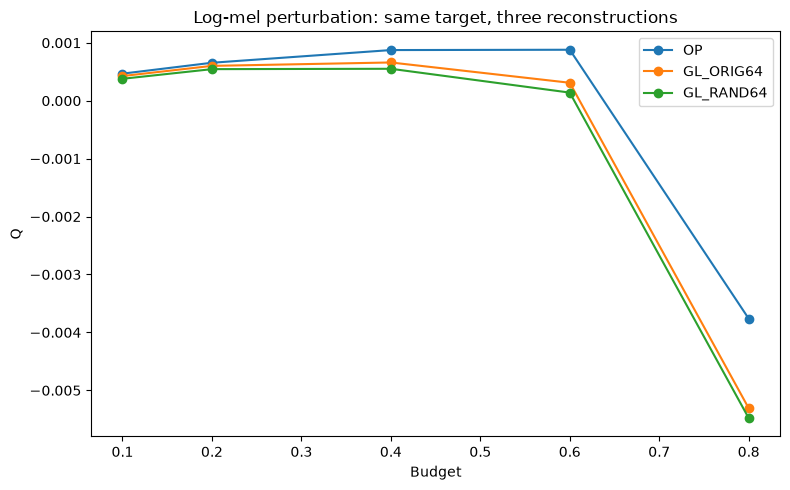

In [11]:
EXAMPLE_SAMPLE = 0
EXAMPLE_DIRECTION = "OUT"

example = results[
    (results["sample_id"] == EXAMPLE_SAMPLE)
    &
    (results["direction"] == EXAMPLE_DIRECTION)
]

plt.figure(figsize=(8, 5))

for operator in [
    "OP",
    "GL_ORIG64",
    "GL_RAND64"
]:
    part = (
        example[
            example["operator"] == operator
        ]
        .sort_values("budget")
    )

    plt.plot(
        part["budget"],
        part["Q"],
        marker="o",
        label=operator
    )

plt.xlabel("Budget")
plt.ylabel("Q")
plt.title(
    "Log-mel perturbation: same target, three reconstructions"
)
plt.legend()
plt.tight_layout()
plt.show()


# O que este notebook mede

Agora existem três níveis claramente separados:

$$
\widetilde{L}
$$

é a intervenção log-mel desejada;

$$
L(\widetilde{x})
$$

é a intervenção realmente realizada depois da inversão e reconstrução;

e:

$$
z_t(\widetilde{x})
$$

é a resposta downstream da CNN.

Isso permite testar não apenas se os operadores mudam a resposta do modelo, mas também se mudam a fidelidade com que a perturbação de features é materializada como áudio.
